# 07 ? Physical Sanity Checks Before MLP Ablation

This notebook validates the physical regime before any MLP ablation. It uses the verified `onsite = 0`, `hopping = -1` convention, defines `E_kin = E0 + 4`, checks low-energy scaling, checks a circle/Bessel sanity benchmark, documents `dE2` near-degeneracy/sensitivity, and inspects edge-discretization diagnostics and sublattice imbalance.

This notebook is not an ML experiment. It does not claim data efficiency, does not claim that the physics-informed features are globally optimal, and does not implement MLP ablation or inverse design.

In [1]:
from __future__ import annotations

import csv
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.geometry import build_superellipse_dot

DATA_PATH = PROJECT_ROOT / "data" / "superellipse_discrete_n_dense_dataset.npz"
REPORT_PATH = PROJECT_ROOT / "reports" / "physics_sanity_checks.csv"
ASSET_DIR = PROJECT_ROOT / "reports" / "assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)

N_VALUES = [1.2, 2.0, 3.0, 4.0]
A_VALUES = [24.0, 27.0, 30.0, 33.0, 36.0]
AR_CIRCLE = 1.0
J01 = 2.4048255577

plt.rcParams.update({
    "figure.figsize": (7.0, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset path: {DATA_PATH}")
print(f"Report path: {REPORT_PATH}")
print(f"Asset directory: {ASSET_DIR}")

Project root: D:\Diplom Physcis ML\Diplom Physcis ML
Dataset path: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_discrete_n_dense_dataset.npz
Report path: D:\Diplom Physcis ML\Diplom Physcis ML\reports\physics_sanity_checks.csv
Asset directory: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets


In [2]:
ONSITE = 0
HOPPING = -1
ENERGY_CONVENTION = "E_kin = E0 + 4"

print("Hamiltonian convention verified from src/geometry.py:")
print(f"onsite = {ONSITE}")
print(f"hopping = {HOPPING}")
print(ENERGY_CONVENTION)

Hamiltonian convention verified from src/geometry.py:
onsite = 0
hopping = -1
E_kin = E0 + 4


In [3]:
with np.load(DATA_PATH) as raw_data:
    dataset_keys = list(raw_data.files)
    data = {key: raw_data[key].copy() for key in dataset_keys}

print(f"Loaded: {DATA_PATH}")

Loaded: D:\Diplom Physcis ML\Diplom Physcis ML\data\superellipse_discrete_n_dense_dataset.npz


In [4]:
E_kin_all = data["E0"] + 4.0

print(f"number of samples: {len(data['a'])}")
print(f"unique n values: {np.unique(data['n'])}")
print(f"unique a values: {np.unique(data['a'])}")
print(f"unique aspect_ratio values: {np.unique(data['aspect_ratio'])}")
print(f"min/max E0: {data['E0'].min():.12f} / {data['E0'].max():.12f}")
print(f"min/max E_kin: {E_kin_all.min():.12f} / {E_kin_all.max():.12f}")
print(f"available keys: {dataset_keys}")

number of samples: 140
unique n values: [1.2 2.  3.  4. ]
unique a values: [24. 27. 30. 33. 36.]
unique aspect_ratio values: [0.67 0.72 0.78 0.83 0.89 0.94 1.  ]
min/max E0: -3.996132993966 / -3.978659036696
min/max E_kin: 0.003867006034 / 0.021340963304
available keys: ['a', 'b', 'aspect_ratio', 'n', 'N_sites', 'E0', 'E1', 'E2', 'E3', 'dE1', 'dE2', 'dE3']


## Sanity-check table

The dataset stores energies and site counts, but not sublattice counts. The sublattice diagnostic is reconstructed from the existing geometry builder without modifying `src/`. For each reconstructed geometry, the site count is checked against the stored `N_sites`.

In [5]:
def isclose_value(value: float, target: float, tol: float = 1e-9) -> bool:
    return math.isclose(float(value), float(target), rel_tol=0.0, abs_tol=tol)


def analytic_superellipse_area(a: float, aspect_ratio: float, n: float) -> float:
    b = a * aspect_ratio
    return 4.0 * a * b * math.gamma(1.0 + 1.0 / n) ** 2 / math.gamma(1.0 + 2.0 / n)


def sublattice_counts(a: float, b: float, n: float) -> tuple[int, int]:
    fsys = build_superellipse_dot(a=a, b=b, n=n)
    n_a = 0
    n_b = 0
    for site in fsys.sites:
        x, y = site.tag
        if (int(x) + int(y)) % 2 == 0:
            n_a += 1
        else:
            n_b += 1
    return n_a, n_b


def format_value(value: object) -> str:
    if isinstance(value, (np.integer, int)):
        return str(int(value))
    if isinstance(value, (np.floating, float)):
        return f"{float(value):.10g}"
    return str(value)


def markdown_table(records: list[dict[str, object]], columns: list[str], max_rows: int | None = None) -> None:
    shown = records if max_rows is None else records[:max_rows]
    header = "| " + " | ".join(columns) + " |"
    divider = "| " + " | ".join(["---"] * len(columns)) + " |"
    lines = [header, divider]
    for record in shown:
        lines.append("| " + " | ".join(format_value(record[col]) for col in columns) + " |")
    if max_rows is not None and len(records) > max_rows:
        lines.append(f"\nShowing {max_rows} of {len(records)} rows.")
    display(Markdown("\n".join(lines)))


def rows_where(records: list[dict[str, object]], **conditions: float) -> list[dict[str, object]]:
    out = records
    for key, expected in conditions.items():
        out = [row for row in out if isclose_value(float(row[key]), expected)]
    return out


def sorted_rows(records: list[dict[str, object]], *keys: str) -> list[dict[str, object]]:
    return sorted(records, key=lambda row: tuple(float(row[key]) for key in keys))


def column(records: list[dict[str, object]], key: str) -> np.ndarray:
    return np.array([row[key] for row in records], dtype=float)


def relative_span(values: np.ndarray) -> float:
    values = np.asarray(values, dtype=float)
    return float((values.max() - values.min()) / values.mean())


sanity_records: list[dict[str, object]] = []
for idx in range(len(data["a"])):
    row = {key: data[key][idx].item() for key in dataset_keys}
    a = float(row["a"])
    b = float(row["b"])
    aspect_ratio = float(row["aspect_ratio"])
    n = float(row["n"])
    n_sites = int(row["N_sites"])

    n_a, n_b = sublattice_counts(a=a, b=b, n=n)
    reconstructed_sites = n_a + n_b
    if reconstructed_sites != n_sites:
        raise ValueError(
            f"Reconstructed N_sites={reconstructed_sites} does not match dataset N_sites={n_sites} "
            f"for a={a}, aspect_ratio={aspect_ratio}, n={n}."
        )

    e_kin = float(row["E0"]) + 4.0
    analytic_area = analytic_superellipse_area(a=a, aspect_ratio=aspect_ratio, n=n)
    delta_n = n_a - n_b

    if isclose_value(n, 2.0) and isclose_value(aspect_ratio, 1.0):
        r_eff = math.sqrt(n_sites / math.pi)
        e_bessel = J01**2 / r_eff**2
        bessel_relative_error = abs(e_kin - e_bessel) / e_bessel
    else:
        r_eff = math.nan
        e_bessel = math.nan
        bessel_relative_error = math.nan

    row.update({
        "E_kin": e_kin,
        "scaled_E0": e_kin * a**2,
        "scaled_dE1": float(row["dE1"]) * a**2,
        "analytic_area": analytic_area,
        "N_sites_over_area": n_sites / analytic_area,
        "R_eff": r_eff,
        "E_Bessel": e_bessel,
        "bessel_relative_error": bessel_relative_error,
        "N_A": n_a,
        "N_B": n_b,
        "delta_N": delta_n,
        "imbalance_ratio": abs(delta_n) / n_sites,
    })
    sanity_records.append(row)

SANITY_COLUMNS = [
    "n",
    "a",
    "aspect_ratio",
    "N_sites",
    "E0",
    "E1",
    "E2",
    "E3",
    "dE1",
    "dE2",
    "dE3",
    "E_kin",
    "scaled_E0",
    "scaled_dE1",
    "analytic_area",
    "N_sites_over_area",
    "R_eff",
    "E_Bessel",
    "bessel_relative_error",
    "N_A",
    "N_B",
    "delta_N",
    "imbalance_ratio",
]

# If pandas is available in another environment, expose the same table as a real DataFrame.
try:
    import pandas as pd  # type: ignore
except ModuleNotFoundError:
    pd = None

sanity_df = pd.DataFrame(sanity_records)[SANITY_COLUMNS] if pd is not None else sanity_records
print(f"Built sanity-check table with {len(sanity_records)} rows.")
print("Reconstructed site counts match stored N_sites for all geometries.")
markdown_table(sorted_rows(sanity_records, "n", "a", "aspect_ratio"), SANITY_COLUMNS[:8], max_rows=8)

Built sanity-check table with 140 rows.
Reconstructed site counts match stored N_sites for all geometries.


| n | a | aspect_ratio | N_sites | E0 | E1 | E2 | E3 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | 24 | 0.67 | 905 | -3.978659037 | -3.953602655 | -3.939448864 | -3.923766432 |
| 1.2 | 24 | 0.72 | 983 | -3.980772671 | -3.9572242 | -3.946309967 | -3.928829784 |
| 1.2 | 24 | 0.78 | 1053 | -3.98237459 | -3.959368161 | -3.952053015 | -3.931437816 |
| 1.2 | 24 | 0.83 | 1127 | -3.983555559 | -3.961446521 | -3.956047513 | -3.935440287 |
| 1.2 | 24 | 0.89 | 1203 | -3.984734611 | -3.963248952 | -3.960042911 | -3.938155617 |
| 1.2 | 24 | 0.94 | 1277 | -3.985681282 | -3.964866973 | -3.96308693 | -3.940801595 |
| 1.2 | 24 | 1 | 1341 | -3.986292156 | -3.965609139 | -3.965609139 | -3.943969567 |
| 1.2 | 27 | 0.67 | 1155 | -3.983237576 | -3.963457273 | -3.952552155 | -3.940003141 |

Showing 8 of 140 rows.

## Low-energy scaling check

Scientific question: "Does the fixed discrete-n superellipse dataset lie in a low-energy quadratic tight-binding regime where the `1/a^2` scaling is physically justified?"

For each fixed `n` at `aspect_ratio = 1.0`, the notebook checks `E_kin * a^2` and, as supporting context for the main gap target, `dE1 * a^2`. Approximate flatness over `a = [24, 27, 30, 33, 36]` supports the plausibility of the scaling in this design window. It is not a proof of the continuum limit.

| n | scaled_E0_min | scaled_E0_max | scaled_E0_relative_span | scaled_dE1_min | scaled_dE1_max | scaled_dE1_relative_span |
| --- | --- | --- | --- | --- | --- | --- |
| 1.2 | 7.792492264 | 7.895718326 | 0.01314247094 | 11.81284488 | 11.92006621 | 0.009021054375 |
| 2 | 5.633281617 | 5.691666492 | 0.010308993 | 8.656958082 | 8.751683955 | 0.01088178125 |
| 3 | 5.13557934 | 5.14745961 | 0.002310672388 | 7.830328903 | 7.85392523 | 0.003009207949 |
| 4 | 4.992976838 | 5.01163982 | 0.003728984681 | 7.542853339 | 7.585057885 | 0.005575522389 |

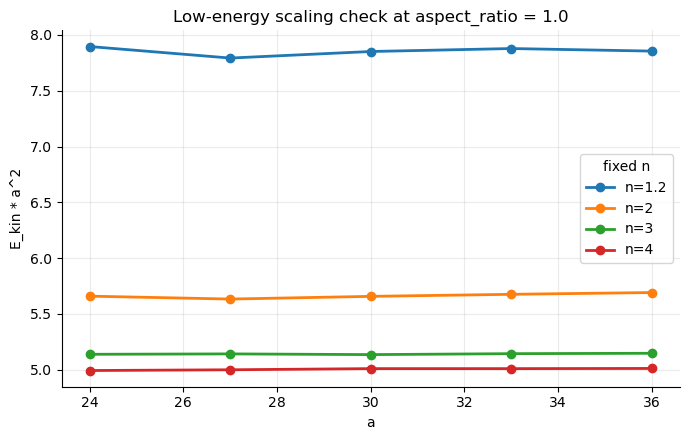

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\e0_kin_a2_scaling_by_n.png


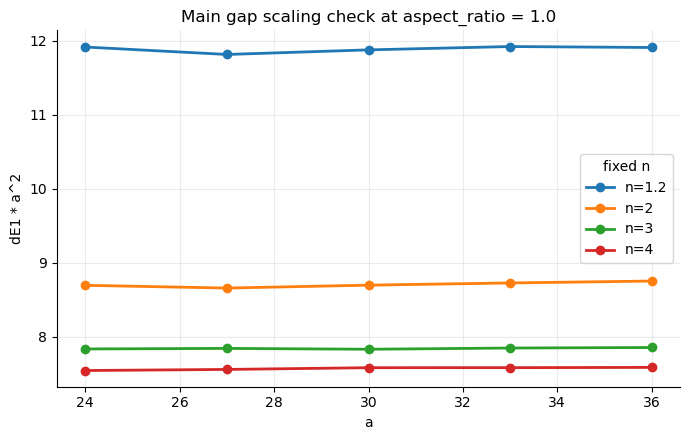

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\de1_a2_scaling_by_n.png


In [6]:
scaling_rows: list[dict[str, object]] = []
for n_value in N_VALUES:
    subset = sorted_rows(rows_where(sanity_records, n=n_value, aspect_ratio=AR_CIRCLE), "a")
    scaled_e0 = column(subset, "scaled_E0")
    scaled_de1 = column(subset, "scaled_dE1")
    scaling_rows.append({
        "n": n_value,
        "scaled_E0_min": scaled_e0.min(),
        "scaled_E0_max": scaled_e0.max(),
        "scaled_E0_relative_span": relative_span(scaled_e0),
        "scaled_dE1_min": scaled_de1.min(),
        "scaled_dE1_max": scaled_de1.max(),
        "scaled_dE1_relative_span": relative_span(scaled_de1),
    })

markdown_table(
    scaling_rows,
    ["n", "scaled_E0_min", "scaled_E0_max", "scaled_E0_relative_span", "scaled_dE1_min", "scaled_dE1_max", "scaled_dE1_relative_span"],
)

fig, ax = plt.subplots()
for n_value in N_VALUES:
    subset = sorted_rows(rows_where(sanity_records, n=n_value, aspect_ratio=AR_CIRCLE), "a")
    ax.plot(column(subset, "a"), column(subset, "scaled_E0"), marker="o", linewidth=2, label=f"n={n_value:g}")
ax.set_xlabel("a")
ax.set_ylabel("E_kin * a^2")
ax.set_title("Low-energy scaling check at aspect_ratio = 1.0")
ax.legend(title="fixed n")
fig.tight_layout()
e0_scaling_path = ASSET_DIR / "e0_kin_a2_scaling_by_n.png"
fig.savefig(e0_scaling_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {e0_scaling_path}")

fig, ax = plt.subplots()
for n_value in N_VALUES:
    subset = sorted_rows(rows_where(sanity_records, n=n_value, aspect_ratio=AR_CIRCLE), "a")
    ax.plot(column(subset, "a"), column(subset, "scaled_dE1"), marker="o", linewidth=2, label=f"n={n_value:g}")
ax.set_xlabel("a")
ax.set_ylabel("dE1 * a^2")
ax.set_title("Main gap scaling check at aspect_ratio = 1.0")
ax.legend(title="fixed n")
fig.tight_layout()
de1_scaling_path = ASSET_DIR / "de1_a2_scaling_by_n.png"
fig.savefig(de1_scaling_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {de1_scaling_path}")

## Circle/Bessel benchmark

For `n = 2.0` and `aspect_ratio = 1.0`, use `R_eff = sqrt(N_sites / pi)` and compare `E_kin` with `E_Bessel = j_01^2 / R_eff^2`, where `j_01 = 2.4048255577`. This is an asymptotic continuum sanity check, not an exact equality on the square lattice and not a proof of the continuum limit.

| a | N_sites | R_eff | E0 | E_kin | E_Bessel | bessel_relative_error |
| --- | --- | --- | --- | --- | --- | --- |
| 24 | 1793 | 23.88994822 | -3.990174893 | 0.009825107252 | 0.01013296962 | 0.03038224564 |
| 27 | 2289 | 26.99280144 | -3.99227259 | 0.007727409625 | 0.007937271531 | 0.02644005636 |
| 30 | 2821 | 29.96585038 | -3.993713913 | 0.006286086967 | 0.006440416354 | 0.02396264141 |
| 33 | 3409 | 32.94113541 | -3.994788099 | 0.005211901193 | 0.005329543718 | 0.02207365804 |
| 36 | 4053 | 35.91810085 | -3.995608282 | 0.004391717972 | 0.004482707756 | 0.02029795129 |

Pre-registered Bessel criterion at a=36: relative_error = 2.029795%
Criterion relative_error < 10%: PASS


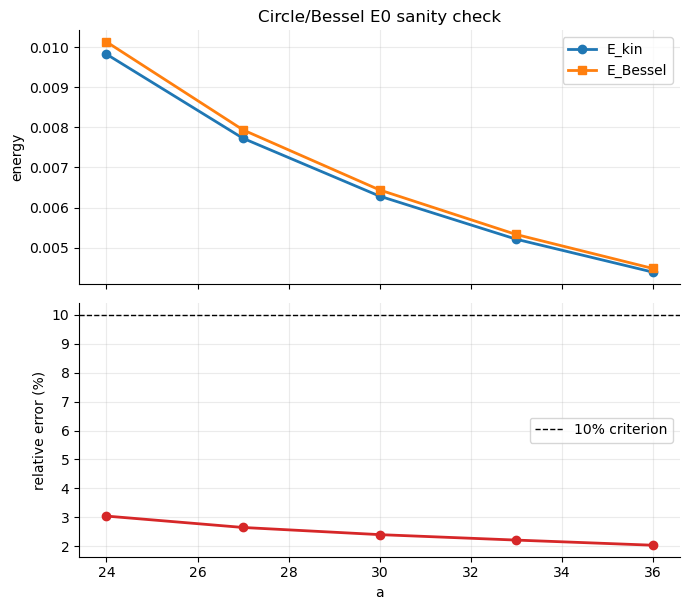

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\circle_bessel_e0_check.png


In [7]:
circle_rows = sorted_rows(rows_where(sanity_records, n=2.0, aspect_ratio=1.0), "a")
bessel_rows: list[dict[str, object]] = []
for row in circle_rows:
    bessel_rows.append({
        "a": row["a"],
        "N_sites": row["N_sites"],
        "R_eff": row["R_eff"],
        "E0": row["E0"],
        "E_kin": row["E_kin"],
        "E_Bessel": row["E_Bessel"],
        "bessel_relative_error": row["bessel_relative_error"],
    })

markdown_table(bessel_rows, ["a", "N_sites", "R_eff", "E0", "E_kin", "E_Bessel", "bessel_relative_error"])

row_a36 = next(row for row in bessel_rows if isclose_value(row["a"], 36.0))
bessel_pass = float(row_a36["bessel_relative_error"]) < 0.10
print(f"Pre-registered Bessel criterion at a=36: relative_error = {row_a36['bessel_relative_error']:.6%}")
print(f"Criterion relative_error < 10%: {'PASS' if bessel_pass else 'FAIL'}")
if not bessel_pass:
    print("The cause must be analyzed before moving to ML conclusions.")

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(7.0, 6.2), sharex=True)
a_vals = column(bessel_rows, "a")
ax0.plot(a_vals, column(bessel_rows, "E_kin"), marker="o", linewidth=2, label="E_kin")
ax0.plot(a_vals, column(bessel_rows, "E_Bessel"), marker="s", linewidth=2, label="E_Bessel")
ax0.set_ylabel("energy")
ax0.set_title("Circle/Bessel E0 sanity check")
ax0.legend()
ax1.plot(a_vals, 100.0 * column(bessel_rows, "bessel_relative_error"), marker="o", color="tab:red", linewidth=2)
ax1.axhline(10.0, color="black", linestyle="--", linewidth=1, label="10% criterion")
ax1.set_xlabel("a")
ax1.set_ylabel("relative error (%)")
ax1.legend()
fig.tight_layout()
bessel_path = ASSET_DIR / "circle_bessel_e0_check.png"
fig.savefig(bessel_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {bessel_path}")

## dE2 diagnostic-only table

The table below is the pre-registered diagnostic slice for `n = 2.0`, `aspect_ratio = 1.0`, and `a in [24, 27, 30, 33, 36]`. The purpose is to show the actual behavior of `dE2` before deciding to keep it out of the main MLP targets.

| a | E0 | E1 | E2 | E3 | dE1 | dE2 | dE3 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 24 | -3.990174893 | -3.975080933 | -3.975080933 | -3.955305125 | 0.01509395977 | 6.528111385e-14 | 0.01977580764 |
| 27 | -3.99227259 | -3.980397476 | -3.980397476 | -3.964869743 | 0.01187511397 | 8.926193118e-14 | 0.01552773306 |
| 30 | -3.993713913 | -3.984051475 | -3.984051475 | -3.971468158 | 0.009662438447 | 1.154631946e-13 | 0.01258331627 |
| 33 | -3.994788099 | -3.986775217 | -3.986775217 | -3.976276001 | 0.008012881328 | 1.296740493e-13 | 0.01049921686 |
| 36 | -3.995608282 | -3.988855439 | -3.988855439 | -3.980004576 | 0.006752842558 | 1.154631946e-13 | 0.008850863585 |

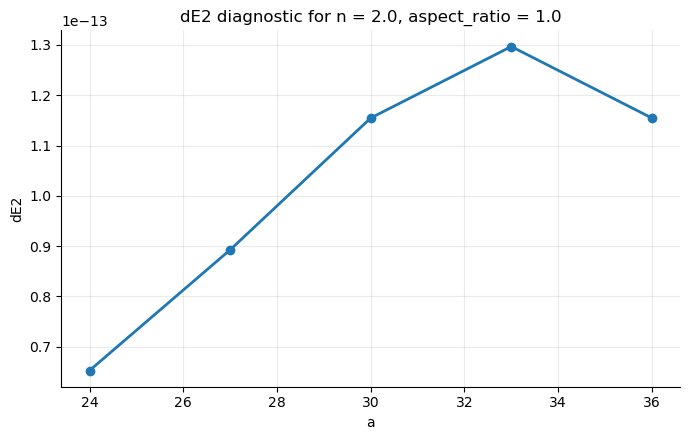

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\de2_near_degeneracy_n2_ar1.png


In [8]:
de2_rows = [
    {key: row[key] for key in ["a", "E0", "E1", "E2", "E3", "dE1", "dE2", "dE3"]}
    for row in circle_rows
]
markdown_table(de2_rows, ["a", "E0", "E1", "E2", "E3", "dE1", "dE2", "dE3"])

fig, ax = plt.subplots()
ax.plot(column(de2_rows, "a"), column(de2_rows, "dE2"), marker="o", linewidth=2)
ax.set_xlabel("a")
ax.set_ylabel("dE2")
ax.set_title("dE2 diagnostic for n = 2.0, aspect_ratio = 1.0")
fig.tight_layout()
de2_path = ASSET_DIR / "de2_near_degeneracy_n2_ar1.png"
fig.savefig(de2_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {de2_path}")

## N_sites / area check

This check compares the discrete site count with the analytic superellipse area for `aspect_ratio = 1.0`. The goal is to flag edge-discretization effects, not to introduce a new model or validation protocol.

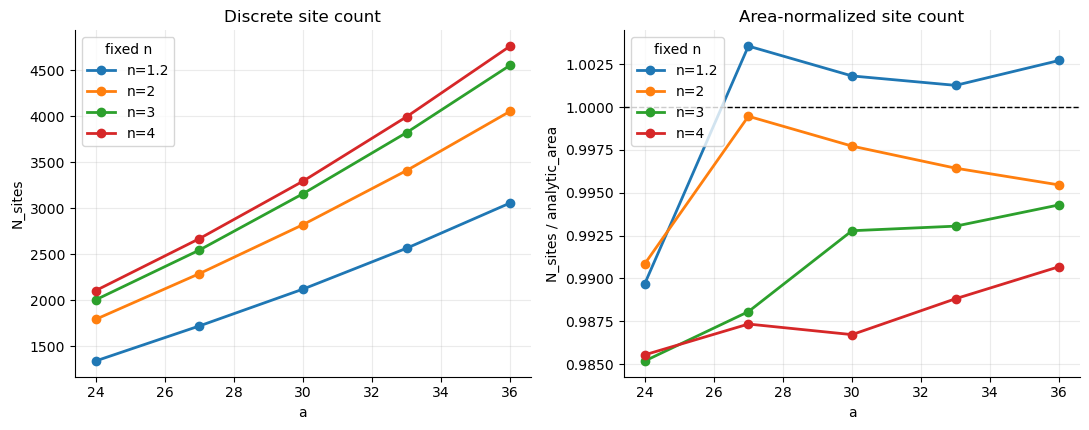

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\nsites_area_ratio_by_n.png
n=1.2 N_sites(a) at aspect_ratio=1.0: [1341, 1721, 2121, 2565, 3057]
successive jumps: [380, 400, 444, 492]
strictly monotonic over a=[24, 27, 30, 33, 36]: True
No non-monotonic site-count jumps were found for this slice.


In [9]:
area_rows = sorted_rows(rows_where(sanity_records, aspect_ratio=1.0), "n", "a")

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.0, 4.4))
for n_value in N_VALUES:
    subset = sorted_rows(rows_where(sanity_records, n=n_value, aspect_ratio=1.0), "a")
    ax0.plot(column(subset, "a"), column(subset, "N_sites"), marker="o", linewidth=2, label=f"n={n_value:g}")
    ax1.plot(column(subset, "a"), column(subset, "N_sites_over_area"), marker="o", linewidth=2, label=f"n={n_value:g}")
ax0.set_xlabel("a")
ax0.set_ylabel("N_sites")
ax0.set_title("Discrete site count")
ax1.set_xlabel("a")
ax1.set_ylabel("N_sites / analytic_area")
ax1.set_title("Area-normalized site count")
ax1.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax0.legend(title="fixed n")
ax1.legend(title="fixed n")
fig.tight_layout()
area_path = ASSET_DIR / "nsites_area_ratio_by_n.png"
fig.savefig(area_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {area_path}")

n12_rows = sorted_rows(rows_where(sanity_records, n=1.2, aspect_ratio=1.0), "a")
n12_sites = column(n12_rows, "N_sites")
n12_jumps = np.diff(n12_sites).astype(int)
n12_monotonic = bool(np.all(n12_jumps > 0))
print(f"n=1.2 N_sites(a) at aspect_ratio=1.0: {[int(x) for x in n12_sites]}")
print(f"successive jumps: {n12_jumps.tolist()}")
print(f"strictly monotonic over a=[24, 27, 30, 33, 36]: {n12_monotonic}")
if n12_monotonic:
    print("No non-monotonic site-count jumps were found for this slice.")
else:
    print("Non-monotonic site-count behavior was found and should be inspected before ML conclusions.")

## Sublattice imbalance check

For each geometry, compute `N_A`, `N_B`, `delta_N = N_A - N_B`, and `imbalance_ratio = abs(delta_N) / N_sites`. This is a diagnostic for lattice/bipartite effects. Zero modes related to sublattice imbalance occur near `E = 0`, i.e. near the middle of the onsite=0 tight-binding band, so they are not expected to directly control the lowest levels `E0` and `E1` unless the data show such a relationship.

max abs(delta_N): 29
max imbalance_ratio: 2.162565%


| n | a | aspect_ratio | N_sites | N_A | N_B | delta_N | imbalance_ratio |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1.2 | 24 | 1 | 1341 | 685 | 656 | 29 | 0.0216256525 |
| 1.2 | 24 | 0.78 | 1053 | 535 | 518 | 17 | 0.01614434948 |
| 1.2 | 27 | 0.78 | 1329 | 655 | 674 | -19 | 0.01429646351 |
| 1.2 | 24 | 0.89 | 1203 | 593 | 610 | -17 | 0.01413133832 |
| 1.2 | 30 | 0.78 | 1651 | 837 | 814 | 23 | 0.01393095094 |
| 1.2 | 30 | 0.94 | 1989 | 1007 | 982 | 25 | 0.01256913022 |
| 1.2 | 27 | 0.89 | 1515 | 767 | 748 | 19 | 0.01254125413 |
| 1.2 | 24 | 0.72 | 983 | 497 | 486 | 11 | 0.01119023398 |

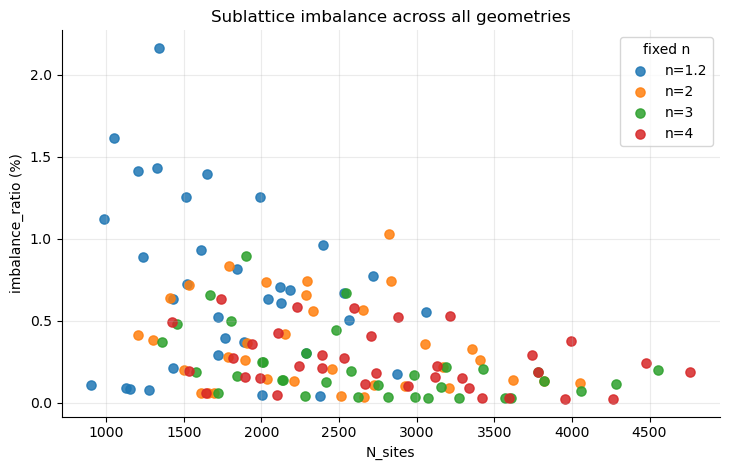

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\assets\sublattice_imbalance_summary.png


In [10]:
max_abs_delta = max(abs(int(row["delta_N"])) for row in sanity_records)
max_imbalance = max(float(row["imbalance_ratio"]) for row in sanity_records)
largest_imbalance_rows = sorted(
    sanity_records,
    key=lambda row: float(row["imbalance_ratio"]),
    reverse=True,
)[:8]

print(f"max abs(delta_N): {max_abs_delta}")
print(f"max imbalance_ratio: {max_imbalance:.6%}")
markdown_table(
    largest_imbalance_rows,
    ["n", "a", "aspect_ratio", "N_sites", "N_A", "N_B", "delta_N", "imbalance_ratio"],
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
for n_value in N_VALUES:
    subset = rows_where(sanity_records, n=n_value)
    ax.scatter(column(subset, "N_sites"), 100.0 * column(subset, "imbalance_ratio"), s=44, alpha=0.85, label=f"n={n_value:g}")
ax.set_xlabel("N_sites")
ax.set_ylabel("imbalance_ratio (%)")
ax.set_title("Sublattice imbalance across all geometries")
ax.legend(title="fixed n")
fig.tight_layout()
imbalance_path = ASSET_DIR / "sublattice_imbalance_summary.png"
fig.savefig(imbalance_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {imbalance_path}")

## Save sanity-check CSV

In [11]:
with REPORT_PATH.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=SANITY_COLUMNS)
    writer.writeheader()
    for row in sanity_records:
        writer.writerow({key: row[key] for key in SANITY_COLUMNS})

print(f"Saved: {REPORT_PATH}")
print(f"Rows: {len(sanity_records)}")
print(f"Columns: {SANITY_COLUMNS}")

Saved: D:\Diplom Physcis ML\Diplom Physcis ML\reports\physics_sanity_checks.csv
Rows: 140
Columns: ['n', 'a', 'aspect_ratio', 'N_sites', 'E0', 'E1', 'E2', 'E3', 'dE1', 'dE2', 'dE3', 'E_kin', 'scaled_E0', 'scaled_dE1', 'analytic_area', 'N_sites_over_area', 'R_eff', 'E_Bessel', 'bessel_relative_error', 'N_A', 'N_B', 'delta_N', 'imbalance_ratio']


## Conclusion

For the current `data/superellipse_discrete_n_dense_dataset.npz` dataset, the Hamiltonian convention is verified as `onsite = 0`, `hopping = -1`, so the continuum-like kinetic energy is `E_kin = E0 + 4`.

At `aspect_ratio = 1.0`, `(E0 + 4) * a^2` is approximately stable over `a = [24, 27, 30, 33, 36]`: the relative span is about 1.31% for `n = 1.2`, 1.03% for `n = 2.0`, 0.23% for `n = 3.0`, and 0.37% for `n = 4.0`. This supports the physical plausibility of the `1/a^2` scaling in this design window, but it is not a proof of the continuum limit.

The largest scaling deviation occurs for `n = 1.2`, plausibly because the rhombus-like boundary is more sensitive to square-lattice discretization. This is not a failure of scaling; it is an expected edge-discretization effect to inspect later in residual analysis.

The circle/Bessel benchmark at `n = 2.0`, `aspect_ratio = 1.0`, and `a = 36` passes the pre-registered criterion: the relative error is about 2.03%, below the 10% threshold.

The `dE2` diagnostic slice for `n = 2.0`, `aspect_ratio = 1.0` shows `dE2` at machine-zero scale, about `1e-13`, for all inspected `a` values, consistent with near-degeneracy/symmetry sensitivity in this slice. This provides factual support for keeping `dE2` diagnostic-only rather than making it a main MLP target.

The discrete area diagnostic gives `N_sites / analytic_area` between about 0.98094 and 1.00761 across all geometries. For `n = 1.2`, `aspect_ratio = 1.0`, `N_sites(a)` is monotonic over the inspected `a` values, with successive jumps `[380, 400, 444, 492]`. These checks reveal finite square-lattice boundary effects at the percent scale.

The sublattice diagnostic finds maximum `abs(delta_N) = 29` and maximum `imbalance_ratio = 2.16%`, with the largest imbalance at `n = 1.2`, `a = 24`, `aspect_ratio = 1.0`. This flags geometry-induced lattice effects, but does not by itself show that sublattice imbalance controls `E0` or `E1`; imbalance-related zero modes occur near `E = 0`, the middle of the onsite=0 tight-binding band.

Limitations: these checks apply only to the selected fixed discrete-n design window and saved dataset. They do not establish data efficiency, do not prove a continuum limit, and do not show that the selected physics-informed features are globally optimal.